**GIẢM CHIỀU VÀ TRỰC QUAN HÓA DỮ LIỆU**



In [ ]:
from sklearn.preprocessing import StandardScaler

standard_cols = ['Height', 'Weight', 'CH2O', 'FAF', 'FCVC', 'TUE',
                 'MTRANS', 'CALC', 'CAEC', 'Gender', 'FAVC', 'SCC',
                 'SMOKE', 'family_history_with_overweight']

standard_scaler = StandardScaler()

X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])


Đoạn mã này sử dụng RobustScaler từ thư viện scikit-learn để chuẩn hóa dữ liệu.

**RobustScaler** là một công cụ trong scikit-learn dùng để chuẩn hóa các đặc trưng
của dữ liệu. Khác với StandardScaler, RobustScaler sử dụng **median** và **IQR**
(Interquartile Range) thay vì mean và std, giúp **giảm ảnh hưởng của outliers**.

Công thức chuẩn hóa

Xét lần lượt từng cột thuộc tính, với mỗi giá trị $x$ thì ta chuẩn hóa thành
$x_{\text{scaled}}$ như sau:

$$
x_{\text{scaled}} = \frac{x - Q_2}{Q_3 - Q_1}
$$

Trong đó:
- $x$ là giá trị của dữ liệu.
- $Q_2$ là **median** (trung vị) của đặc trưng — giá trị ở vị trí 50%.
- $Q_1$ là **quartile thứ nhất** — giá trị ở vị trí 25%.
- $Q_3$ là **quartile thứ ba** — giá trị ở vị trí 75%.
- $IQR = Q_3 - Q_1$ là khoảng tứ phân vị, đo độ phân tán của 50% dữ liệu giữa.

In [ ]:
from sklearn.preprocessing import RobustScaler

robust_cols = ['Age', 'NCP']

robust_scaler = RobustScaler()

X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

X_train.to_csv("X_train_scaled.csv", index=False)
X_test.to_csv("X_test_scaled.csv", index=False)

Dữ liệu sau khi chuẩn hóa

In [ ]:
X_train.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS
0,0.523702,-1.018450,-0.803003,0.719123,0.532293,0.349772,1.087913,0.0,-0.212823,-0.155794,-0.850559,0.464368,-1.081814,0.026802,-0.294954,0.478175
1,0.526680,-1.018450,-0.496412,0.969880,0.532293,0.349772,1.087913,0.0,-0.212823,-0.155794,1.258912,0.464368,-1.198990,-0.842365,-0.294954,0.478175
2,-0.805134,0.981884,0.512332,-0.015543,0.532293,0.349772,0.914154,0.0,-0.212823,-0.155794,1.204814,0.464368,0.258885,-1.009196,-0.294954,0.478175
3,-0.139227,-1.018450,-0.026553,-0.800929,0.532293,-2.859006,1.087913,0.0,4.698737,-0.155794,-0.003599,0.464368,1.191307,0.583831,4.083413,0.478175
4,0.102430,0.981884,-0.346817,-0.453961,0.532293,0.349772,-0.781717,0.0,-0.212823,-0.155794,-0.003599,0.464368,-1.044621,2.212137,-0.294954,0.478175


## 2.3 Phân tích thành phần chính (PCA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score


In [ ]:
X_train_scaled = pd.read_csv("/content/X_train_scaled.csv")
X_test_scaled = pd.read_csv("/content/X_test_scaled.csv")

 Thực hiện giảm chiều bằng PCA

pca = PCA()
*   PCA(): Đây là cách khởi tạo một đối tượng của lớp PCA từ thư viện scikit-learn.
*   Khi khởi tạo PCA mà không truyền thêm tham số, PCA sẽ giữ lại tất cả các thành phần chính của dữ liệu.

fit_transform(): Đây là một phương thức kết hợp hai bước trong quá trình PCA:


*   fit(): Phương thức này học các thành phần chính từ bộ dữ liệu huấn luyện (X_train_scaled). Nó sẽ tính toán ma trận hiệp phương sai của dữ liệu và tìm các thành phần chính.
*   transform(): Sau khi đã "học" xong các thành phần chính, phương thức transform() sẽ chiếu dữ liệu gốc vào không gian mới được tạo ra bởi các thành phần chính.


In [ ]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

###Phân tích phương sai giải thích

Đây là thuộc tính của đối tượng PCA sau khi đã thực hiện fit() trên dữ liệu. Nó trả về tỷ lệ phương sai giải thích của mỗi thành phần chính.
Phương sai giải thích cho biết mức độ quan trọng của mỗi thành phần chính trong việc giải thích sự biến thiên trong dữ liệu.
Kết quả explained_variance là một mảng chứa tỷ lệ phương sai giải thích của từng thành phần chính.

np.cumsum(): Đây là hàm trong thư viện NumPy tính tổng dồn của một mảng. Cộng dồn các giá trị của explained_variance để tính tổng phương sai giải thích của tất cả các thành phần chính đến một thành phần chính cụ thể.

cumulative_variance: Kết quả là một mảng chứa tổng phương sai giải thích tích lũy của các thành phần chính.


In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

 Vẽ biểu đồ phương sai giải thích PCA.
Biểu đồ này sẽ giúp bạn hiểu được mức độ đóng góp của các thành phần chính trong PCA vào phương sai tổng thể, với một ngưỡng được chỉ ra để xác định số lượng thành phần chính cần thiết để giải thích ít nhất 95% phương sai của dữ liệu.

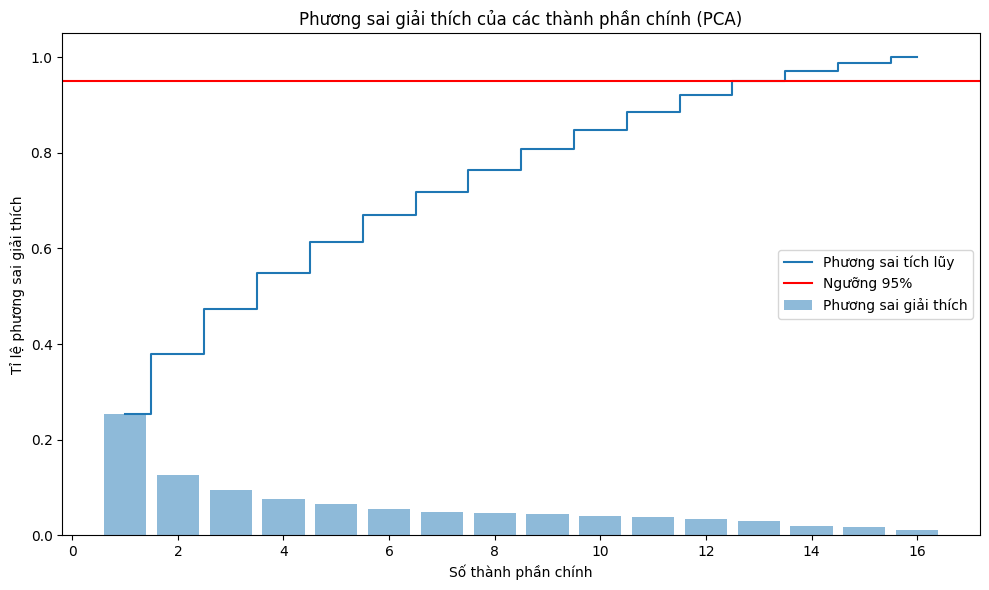

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center',
        label='Phương sai giải thích')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Phương sai tích lũy')
plt.axhline(y=0.95, color='r', linestyle='-', label='Ngưỡng 95%')
plt.xlabel('Số thành phần chính')
plt.ylabel('Tỉ lệ phương sai giải thích')
plt.title('Phương sai giải thích của các thành phần chính (PCA)')
plt.legend(loc='best')
plt.tight_layout()

Từ kết quả trên cho thấy cần ít nhất 13 thành phần chính để tổng phương sai giữ lại là trên 95%

In [ ]:
y_test = pd.read_csv("/content/y_test.csv")
y_train = pd.read_csv("/content/y_train.csv")
pca = PCA(n_components=13)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_columns = [f'PC{i+1}' for i in range(13)]

df_train_pca = pd.DataFrame(X_train_pca, columns=pca_columns)
df_train_pca['NObeyesdad'] = y_train.values.ravel()

df_test_pca = pd.DataFrame(X_test_pca, columns=pca_columns)
df_test_pca['NObeyesdad'] = y_test.values.ravel()

df_train_pca.to_csv("X_train_pca.csv", index=False)
df_test_pca.to_csv("X_test_pca.csv", index=False)

##2.1 Chia tập training set (tập huấn luyện) và testing set (tập thử)

In [ ]:
encoded = pd.read_csv("/content/obesity_encoded.csv")
X = encoded.drop(['NObeyesdad'], axis=1)
y = encoded['NObeyesdad']

Chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set)

train_test_split: Đây là hàm từ thư viện scikit-learn, được sử dụng để chia tập dữ liệu thành hai phần: tập huấn luyện và tập kiểm tra.

test_size=0.3:
*   test_size chỉ định tỷ lệ dữ liệu sẽ được dùng làm tập kiểm tra.
*   Ở đây, test_size=0.3 có nghĩa là 30% dữ liệu sẽ được sử dụng cho tập kiểm tra, và 80% dữ liệu còn lại sẽ được dùng cho tập huấn luyện.

random_state=42:
*   random_state là một tham số được sử dụng để đảm bảo tính tái lập (reproducibility).
*   Khi ta thiết lập random_state=42, việc chia dữ liệu sẽ luôn tạo ra cùng một kết quả mỗi khi bạn chạy mã, đảm bảo kết quả là nhất quán khi bạn thử lại.
*   Giá trị 42 không có ý nghĩa đặc biệt, nó chỉ là một số được dùng làm hạt ngẫu nhiên (random seed).

stratify=y:
*   Tác dụng của nó là chia đều tỉ lệ cho cả các mẫu dữ liệu nhãn M và nhãn B.

Kết quả của train_test_split: Hàm này trả về bốn biến:

*   X_train: Tập đặc trưng huấn luyện, chứa 70% của X: gồm 70% mẫu dữ liệu của nhãn M, 70% mẫu dữ liệu của nhãn B.
*   X_test: Tập đặc trưng kiểm tra, chứa 30% của X: gồm 30% mẫu dữ liệu của nhãn M, 30% mẫu dữ liệu của nhãn B.
*   y_train: Tập nhãn huấn luyện, chứa 70% của y: là nhãn của X_train, tỷ lệ như trên.
*   y_test: Tập nhãn kiểm tra, chứa 30% của y.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#xuất file csv
x_train.to_csv("X_train.csv", index=False)
x_test.to_csv("X_test.csv", index=False)
y_train.to_frame("NObeyesdad").to_csv("y_train.csv", index=False)
y_test.to_frame("NObeyesdad").to_csv("y_test.csv", index=False)

##2.2 Chuẩn hóa dữ liệu


Việc chuẩn hóa dữ liệu là một bước cực kỳ quan trọng trước khi áp dụng các phương pháp giảm chiều dữ liệu. Nếu các đặc trưng có thang đo khác nhau (ví dụ: một biến từ 0–1, biến khác từ 0–1000), mô hình sẽ bị “thiên vị” về những biến có giá trị lớn hơn, dẫn đến kết quả sai lệch. Sử dụng các phương pháp như StandardScaler giúp đưa dữ liệu về phân phối chuẩn với trung bình bằng 0 và độ lệch chuẩn bằng 1, từ đó cải thiện tốc độ hội tụ và độ chính xác của mô hình. Trong khi đó, RobustScaler lại là lựa chọn tốt hơn khi dữ liệu chứa nhiều outlier, vì nó sử dụng median và IQR (khoảng tứ phân vị) thay vì mean và standard deviation, giúp giảm ảnh hưởng của các giá trị ngoại lai. Việc chọn đúng phương pháp chuẩn hóa không chỉ giúp mô hình học tốt hơn mà còn đảm bảo tính ổn định và khả năng tổng quát hóa trên dữ liệu mới.

Để quyết định nên dùng phương pháp chuẩn hóa nào tốt nhất cho từng biến, ta sẽ đánh giá skew và outlier của các feature cần chuẩn hóa.

tuy nhiên các đặc trưng được mã hóa bằng Binary Encoding và Ordinal Encoding chủ yếu mang tính chất phân loại rời rạc với miền giá trị nhỏ, do đó nhóm sử dụng StandardScaler.

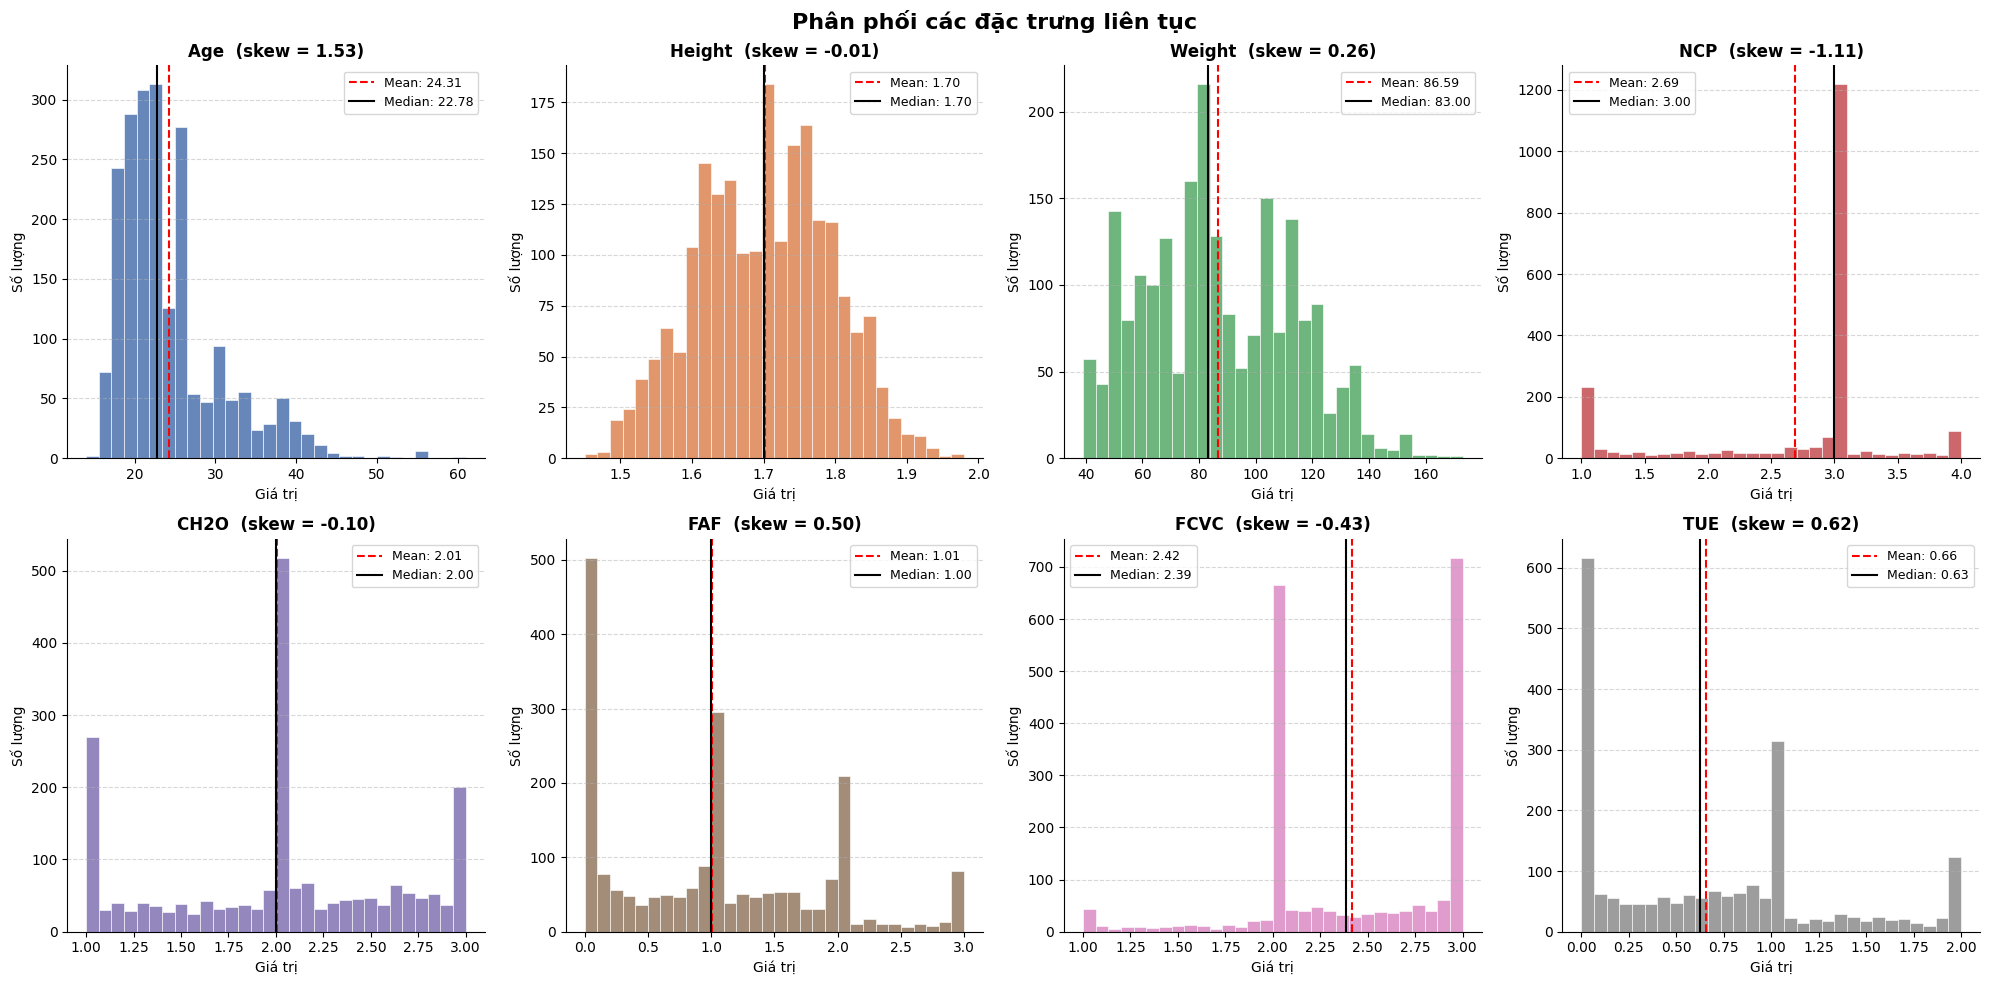

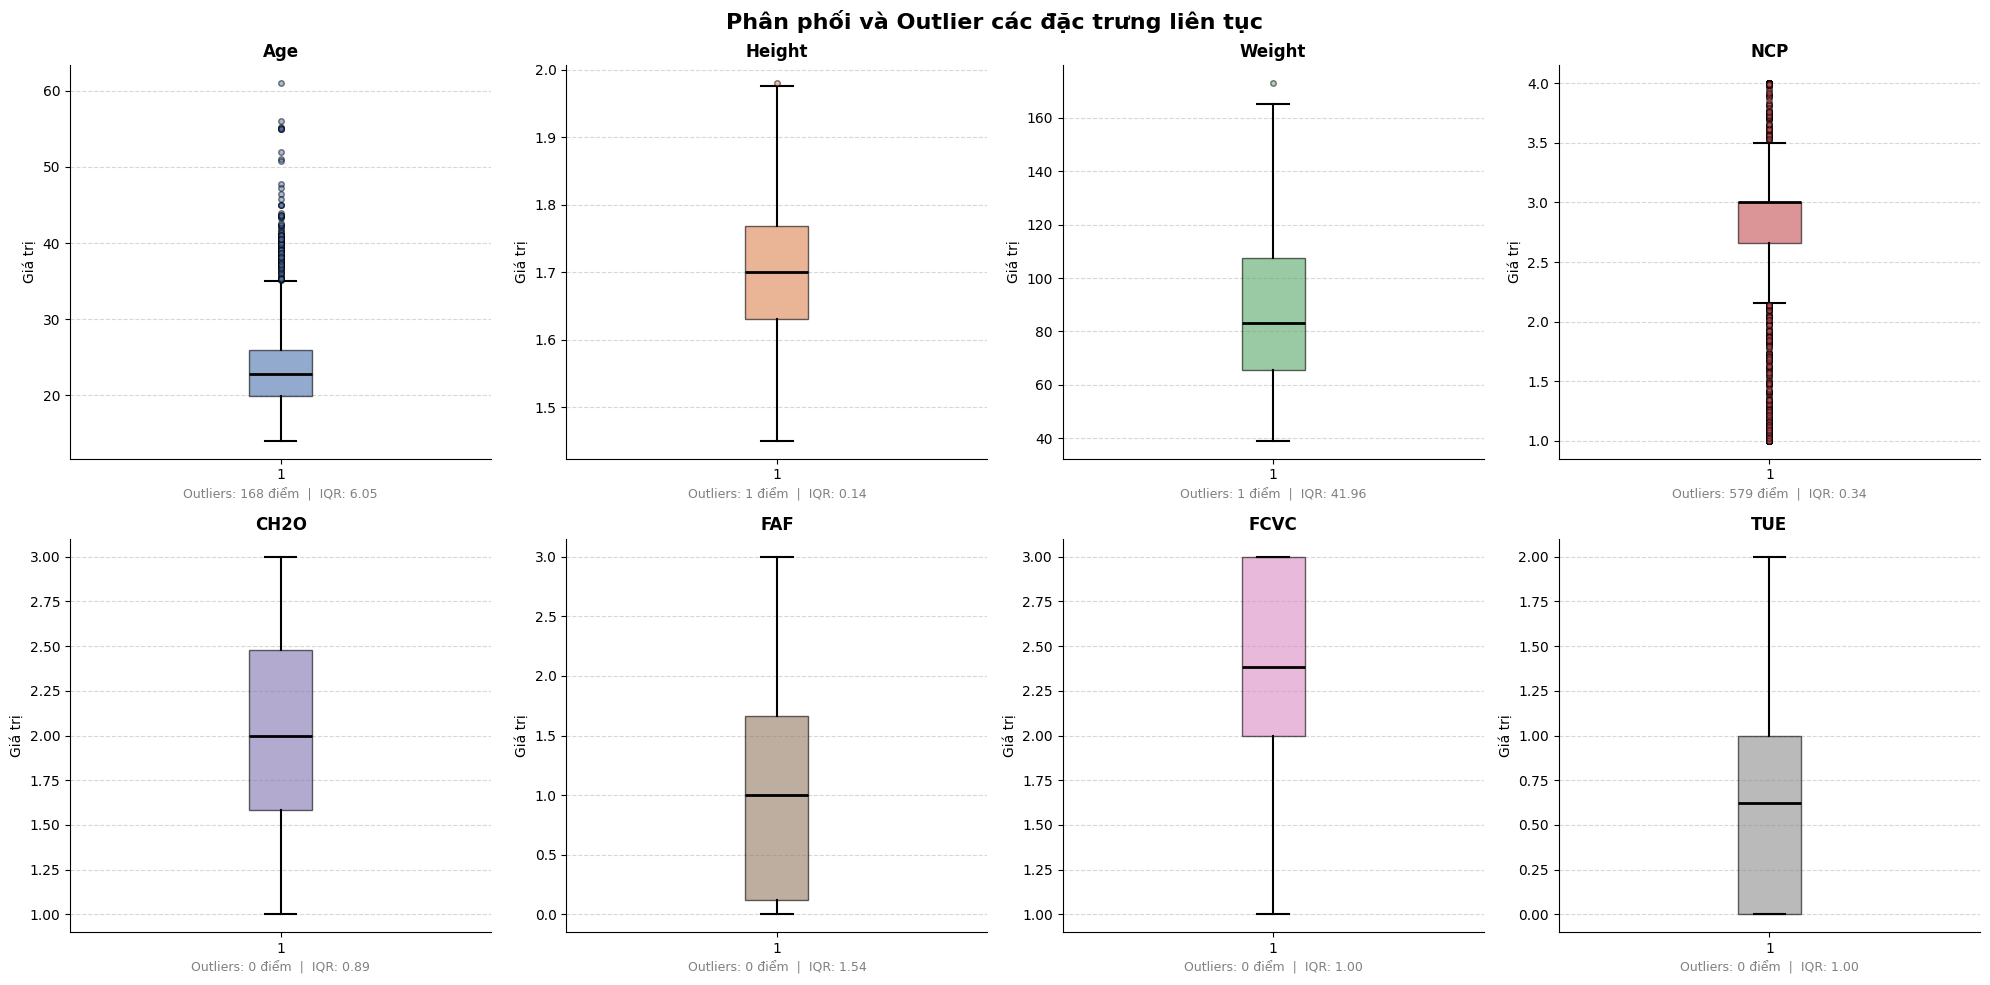

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_encoded = pd.read_csv("/content/obesity_encoded.csv")

cols   = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF','FCVC', 'TUE']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

#histogram

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Phân phối các đặc trưng liên tục', fontsize=16, fontweight='bold')

for i, (col, color) in enumerate(zip(cols, colors)):
    ax = axes[i // 4][i % 4]
    skew_val = df_encoded[col].skew()

    ax.hist(df_encoded[col].dropna(), bins=30, color=color,
            edgecolor='white', linewidth=0.5, alpha=0.85)

    ax.axvline(df_encoded[col].mean(),   color='red',   linestyle='--', linewidth=1.5,
               label=f'Mean: {df_encoded[col].mean():.2f}')
    ax.axvline(df_encoded[col].median(), color='black', linestyle='-',  linewidth=1.5,
               label=f'Median: {df_encoded[col].median():.2f}')

    ax.set_title(f'{col}  (skew = {skew_val:.2f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Giá trị', fontsize=10)
    ax.set_ylabel('Số lượng', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('histogram.png', dpi=150, bbox_inches='tight')
plt.show()


# 2. BOXPLOT

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Phân phối và Outlier các đặc trưng liên tục', fontsize=16, fontweight='bold')

for i, (col, color) in enumerate(zip(cols, colors)):
    ax = axes[i // 4][i % 4]

    ax.boxplot(df_encoded[col].dropna(), patch_artist=True, vert=True,
               flierprops=dict(marker='o', markerfacecolor=color, markersize=4, alpha=0.5),
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.6),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))

    q1  = df_encoded[col].quantile(0.25)
    q3  = df_encoded[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((df_encoded[col] < q1 - 1.5 * iqr) | (df_encoded[col] > q3 + 1.5 * iqr)).sum()

    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Giá trị', fontsize=10)
    ax.set_xlabel(f'Outliers: {n_outliers} điểm  |  IQR: {iqr:.2f}', fontsize=9, color='gray')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

1. Đánh giá độ lệch (skewness):
Kết quả quan sát từ biểu đồ cho thấy phân phối của một số đặc trưng không còn tính đối xứng. Cụ thể, biến Age có hệ số lệch skew = 1.53 và NCP có skew = 1.11, đều vượt ngưỡng 1 – mức thường được xem là biểu hiện của độ lệch lớn. Điều này cho thấy phân phối của hai biến này bị lệch phải rõ rệt, với phần đuôi kéo dài về phía các giá trị lớn. Ngược lại, các đặc trưng còn lại có hệ số lệch từ nhỏ đến trung bình, cho thấy phân phối tương đối cân đối và gần với phân phối chuẩn hơn.

2. Đánh giá giá trị ngoại lai (outliers):
Dựa trên biểu đồ, có thể nhận thấy hai đặc trưng Age và NCP xuất hiện nhiều giá trị ngoại lai. Các outlier này nằm xa so với phần lớn dữ liệu, góp phần làm gia tăng độ lệch của phân phối và có thể ảnh hưởng tiêu cực đến quá trình huấn luyện mô hình, đặc biệt đối với các thuật toán nhạy cảm với khoảng cách hoặc phân phối dữ liệu. Do đó, cần cân nhắc áp dụng các phương pháp xử lý phù hợp như biến đổi dữ liệu hoặc sử dụng kỹ thuật chuẩn hóa bền vững để giảm thiểu tác động của các giá trị ngoại lai.


Từ nhưng kết luận trên ta sẽ áp dụng:
- Phương pháp chuẩn hóa robust cho đặc trưng: Age, NCP
- Phương pháp chuẩn hóa standard cho đặc trưng: Height, Weight, CH2O, FAF, FCVC ,TUE,


Đoạn mã này sử dụng StandardScaler từ thư viện scikit-learn để chuẩn hóa dữ liệu. Việc chuẩn hóa là một bước rất quan trọng trong quy trình học máy, đặc biệt là đối với các mô hình nhạy cảm với sự khác biệt về đơn vị đo của các đặc trưng (như SVM, KNN, Logistic Regression,...).

StandardScaler: Đây là một công cụ trong scikit-learn dùng để chuẩn hóa các đặc trưng của dữ liệu bằng cách tạo ra dữ liệu có phân phối chuẩn (normal distribution) với:

*   Mean (trung bình) = 0.
*   Standard Deviation (độ lệch chuẩn) = 1.

**Công thức chuẩn hóa**

Xét lần lượt từng cột thuộc tính, với mỗi giá trị \( x \) thì ta chuẩn hóa thành $ x_{\text{scaled}} $ như sau:



$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

Trong đó:
- \( x \) là giá trị của dữ liệu.
- \( N \) là số mẫu dữ liệu, ở đây cụ thể bằng 569.
- \( mu \) là giá trị trung bình của đặc trưng, được tính như sau:

$$
\mu = \frac{x_1 + x_2 + x_3 + \cdots + x_N}{N}
$$

- \( sigma \) là độ lệch chuẩn của đặc trưng, được tính như sau:

$$
\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}
$$

In [ ]:
X_train = pd.read_csv("/content/X_train.csv")
X_test = pd.read_csv("/content/X_test.csv")
y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")

TRỰC QUAN HÓA DỮ LIỆU PCA

Trực quan hóa dữ liệu sau khi áp dụng PCA bằng cách vẽ biểu đồ phân tán cho hai thành phần chính đầu tiên. Việc này giúp hình dung sự phân bố và mối quan hệ giữa các mẫu dữ liệu trong không gian giảm chiều.

Màu sắc của các điểm dựa trên nhãn lớp (y_train) giúp ta thấy rõ sự phân tách giữa các nhóm dữ liệu khác nhau, từ đó dễ dàng đánh giá liệu dữ liệu có thể được phân loại rõ ràng hay không trong không gian giảm chiều.

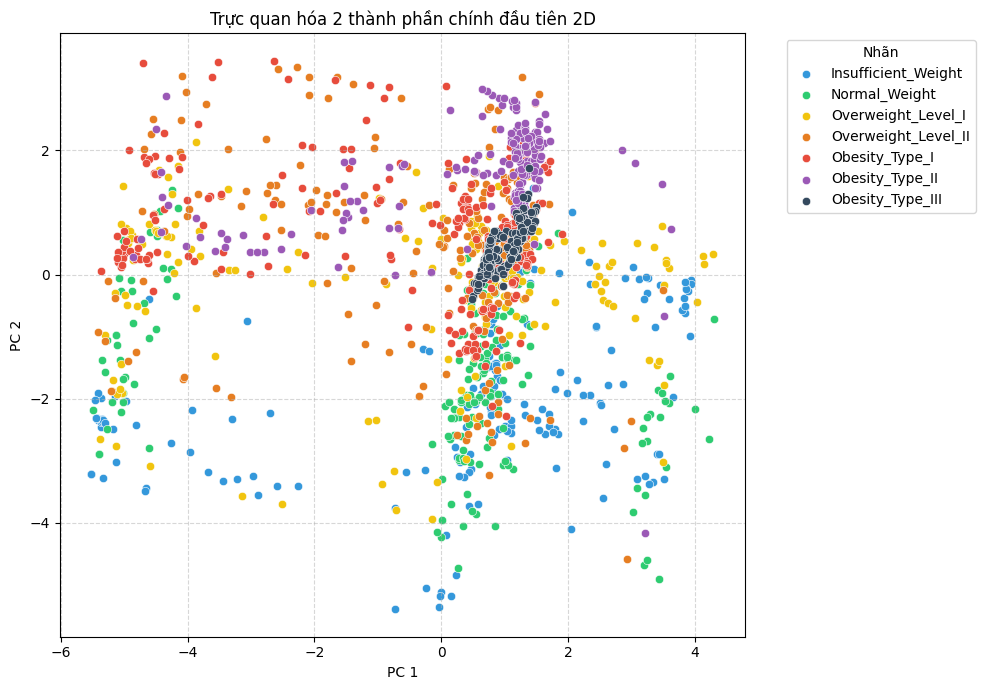

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

X_pca = pd.read_csv("X_train_pca.csv")
X_pca = X_pca.drop(X_pca.columns[13], axis=1)
y_train = pd.read_csv("y_train.csv")

label_map = {
    0: "Insufficient_Weight",
    1: "Normal_Weight",
    2: "Overweight_Level_I",
    3: "Overweight_Level_II",
    4: "Obesity_Type_I",
    5: "Obesity_Type_II",
    6: "Obesity_Type_III"
}

y_train['NObeyesdad'] = y_train['NObeyesdad'].map(label_map)

df = pd.concat([X_pca.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)

label_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

colors = ["#3498db", "#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#9b59b6", "#34495e"]

plt.figure(figsize=(10, 7))

for label, color in zip(label_order, colors):
    subset = df[df["NObeyesdad"] == label]
    if not subset.empty:
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=label,
            color=color,
            alpha=1,
            edgecolors='w',
            linewidth=0.4
        )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Trực quan hóa 2 thành phần chính đầu tiên 2D")
plt.legend(title="Nhãn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Tiếp tục trực quan hóa với 4 thành phần chính đầu tiên

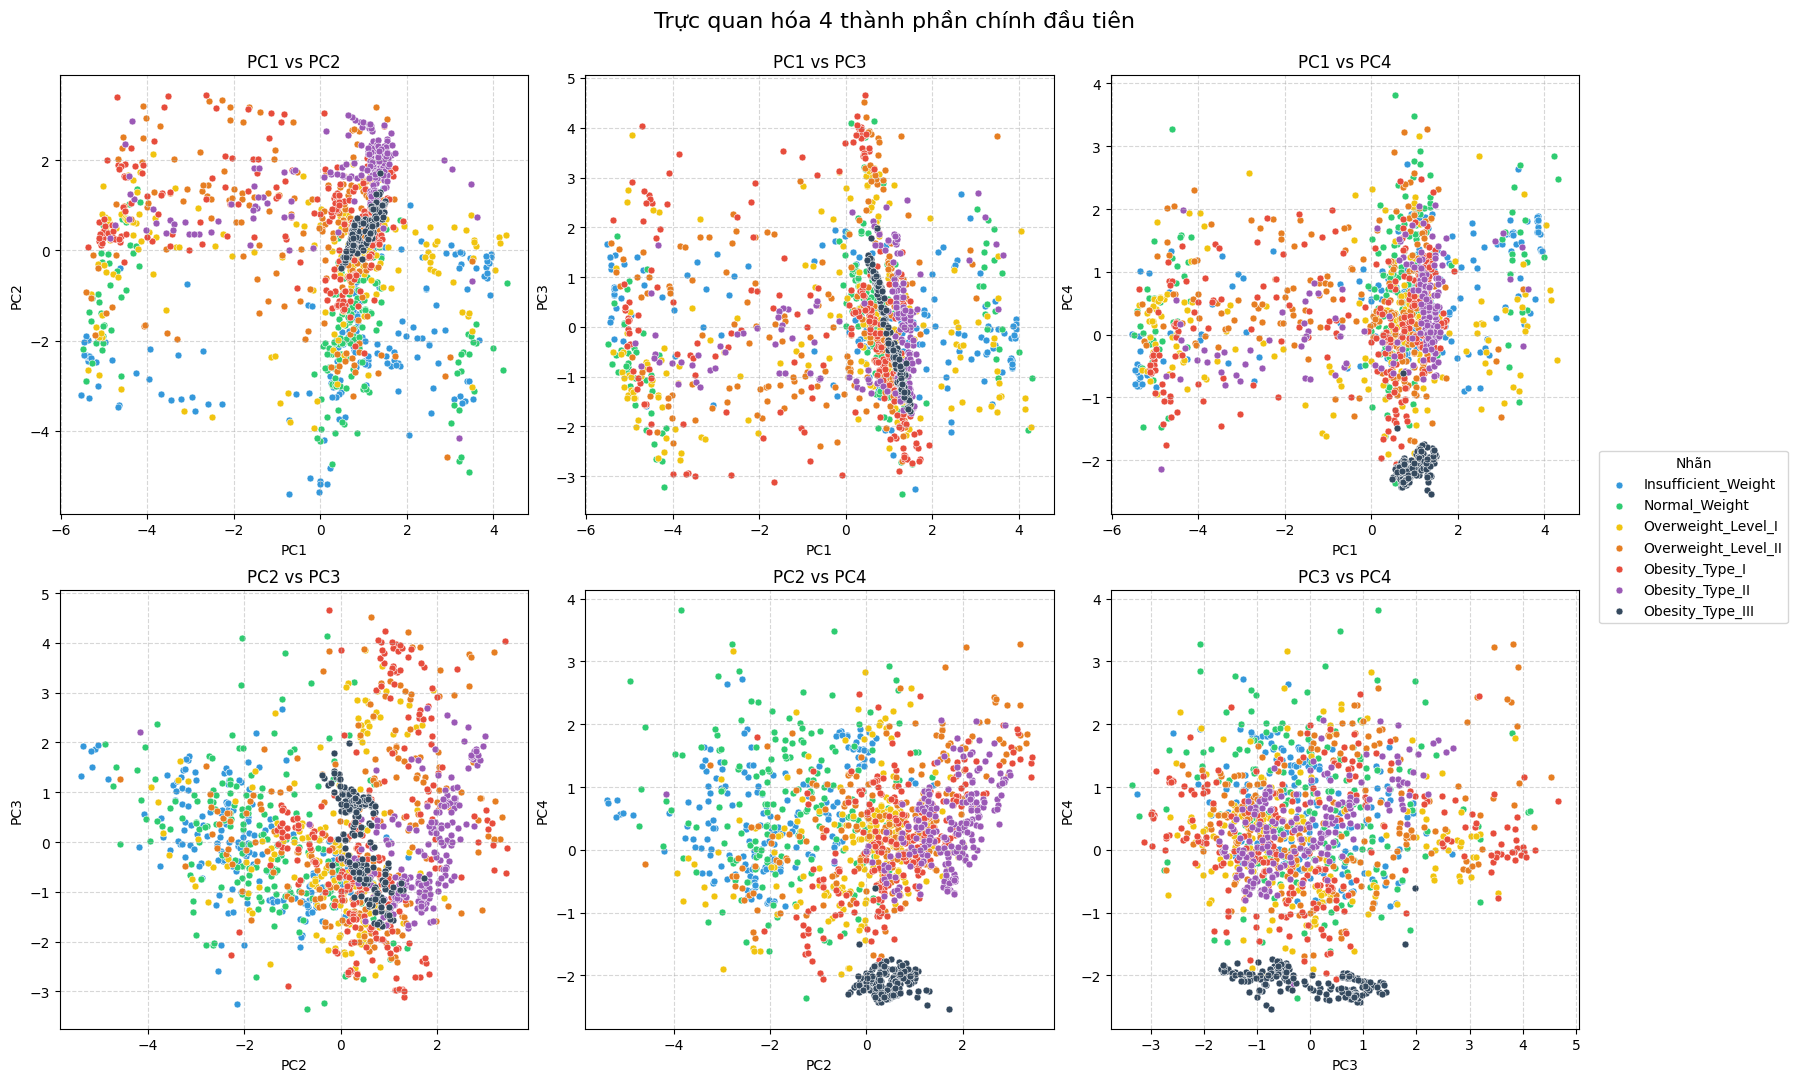

In [ ]:
import matplotlib.pyplot as plt

pc_pairs = [
    ('PC1', 'PC2'), ('PC1', 'PC3'), ('PC1', 'PC4'),
    ('PC2', 'PC3'), ('PC2', 'PC4'), ('PC3', 'PC4')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (pc_x, pc_y) in enumerate(pc_pairs):
    ax = axes[i]
    for label, color in zip(label_order, colors):
        subset = df[df["NObeyesdad"] == label]
        if not subset.empty:
            ax.scatter(
                subset[pc_x],
                subset[pc_y],
                label=label,
                color=color,
                alpha=1,
                edgecolors='w',
                linewidth=0.4,
                s=25
            )
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.set_title(f"{pc_x} vs {pc_y}")
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Nhãn", loc='center right', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.subplots_adjust(right=0.88, top=0.92)
plt.suptitle("Trực quan hóa 4 thành phần chính đầu tiên", fontsize=16)

plt.show()

ĐÁNH GIÁ KẾT QUẢ SAU GIẢM CHIỀU

Kết quả phân tích cho thấy chỉ phân tách tốt một số lớp nhất định, trong khi phần lớn các lớp còn lại vẫn bị chồng lấp đáng kể.

Về mặt tích cực, lớp Obesity_Type_III (xám) được tách biệt khá rõ ràng trong hầu hết các cặp thành phần chính, đặc biệt nổi bật ở các biểu đồ PC1 vs PC4 và PC3 vs PC4. Điều này cho thấy nhóm dữ liệu này có đặc trưng rất riêng biệt và dễ phân biệt so với các lớp còn lại. Đồng thời, PC1 cũng đóng vai trò quan trọng trong việc phân tách, khi quan sát trên mặt phẳng PC1 vs PC2 có thể thấy Obesity_Type_III tập trung về một phía rõ rệt, thể hiện khả năng đóng góp của thành phần này trong việc tách nhóm dữ liệu.

Tuy nhiên, hạn chế lớn nhất nằm ở các lớp còn lại gồm Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I và Obesity_Type_II. Các lớp này chồng lấp gần như hoàn toàn trên tất cả các cặp thành phần chính, cho thấy không tồn tại một không gian tuyến tính nào trong các PC có thể phân tách tốt giữa chúng. Điều này phản ánh mức độ tương đồng cao giữa các nhóm trung gian, khiến việc phân biệt trở nên khó khăn.

Bên cạnh đó, các thành phần PC2, PC3 và PC4 hầu như không đóng góp đáng kể vào việc phân tách lớp. Quan sát cho thấy dữ liệu phân bố trộn lẫn ngẫu nhiên theo nhiều hướng, không hình thành ranh giới rõ ràng giữa các lớp. Ngoài ra, không xuất hiện xu hướng phân bố dạng gradient theo mức độ béo phì như kỳ vọng ban đầu, cho thấy cấu trúc dữ liệu trong không gian giảm chiều chưa phản ánh rõ tính thứ bậc giữa các nhóm.

## 2.4 Phân tích phân biệt tuyến tính (LDA)

### Thực hiện LDA
Đoạn mã này thực hiện giảm chiều dữ liệu bằng phương pháp Linear Discriminant Analysis (LDA). Mục đích của LDA là giảm số lượng đặc trưng (features) trong dữ liệu trong khi vẫn giữ được khả năng phân biệt giữa các lớp dữ liệu.

1.   Xác định số lớp trong tập huấn luyện: np.unique(y_train) trả về các giá trị duy nhất trong y_train, và len() trả về số lượng các lớp khác nhau.
2.   Xác định số thành phần cần giữ lại: Số lượng thành phần (components) trong LDA bị giới hạn bởi số lớp - 1 và số lượng đặc trưng trong dữ liệu. Nếu số lượng lớp ít hơn số đặc trưng, số thành phần được chọn sẽ là số lớp - 1. Ngược lại, nếu số lớp nhiều hơn số đặc trưng, số thành phần chỉ có thể tối đa bằng số đặc trưng.
3.   Khởi tạo mô hình LDA: Dùng thư viện sklearn để tạo một mô hình LDA, và chỉ định số thành phần (số chiều giảm xuống).
4.   Áp dụng phương pháp LDA vào tập huấn luyện.
5.   Giảm chiều dữ liệu kiểm tra



In [ ]:
X_train_scaled = pd.read_csv("/content/X_train_scaled.csv")
X_test_scaled = pd.read_csv("/content/X_test_scaled.csv")
n_classes = len(np.unique(y_train))
n_components_lda = min(n_classes - 1, X_train_scaled.shape[1])
lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_lda = lda.fit_transform(X_train_scaled, y_train)
print("Số components:", lda.scalings_.shape[1])
print("Explained variance ratio:", lda.explained_variance_ratio_)
print("Cumulative variance:", lda.explained_variance_ratio_.cumsum())

Số components: 6
Explained variance ratio: [0.93100072 0.04801958 0.00965614 0.00527369 0.00330736 0.00274251]
Cumulative variance: [0.93100072 0.9790203  0.98867644 0.99395013 0.99725749 1.        ]


Khác với PCA, số thành phần chính thường được chọn dựa trên lượng phương sai dữ liệu được giữ lại (ví dụ 95%). Tuy nhiên, đối với Linear Discriminant Analysis, mục tiêu chính không phải là giữ lại phương sai mà là tối đa khả năng phân tách giữa các lớp dữ liệu.

Vì vậy, số chiều LD phù hợp không cố định mà phụ thuộc vào mô hình học máy được sử dụng phía sau. Một số mô hình có thể hoạt động tốt với ít thành phần LD do dữ liệu đã được phân tách rõ ràng, trong khi các mô hình khác cần nhiều thành phần hơn để giữ đủ thông tin phân biệt.

Do đó, số lượng thành phần LDA thường được lựa chọn bằng cách thử nhiều giá trị LD khác nhau và đánh giá hiệu năng mô hình thông qua Cross-Validation với các chỉ số như Accuracy hoặc F1-score. Giá trị LD cho kết quả đánh giá tốt nhất sẽ được chọn làm số chiều tối ưu.




TRỰC QUAN HÓA DỮ LIỆU LDA

Trong phần trực quan hóa dữ liệu, nhóm lựa chọn 2 thành phần LD nhằm thuận tiện cho việc phân tích và quan sát sự phân tách giữa các lớp trên tập train. Tuy nhiên, đối với các mô hình được sử dụng ở các bước sau như Support Vector Machine hay Logistic-Softmax, số lượng thành phần LD sẽ được lựa chọn riêng sao cho tối ưu hiệu năng của từng mô hình

In [ ]:
y_test = pd.read_csv("/content/y_test.csv")
y_train = pd.read_csv("/content/y_train.csv")

n_classes = len(np.unique(y_train))
max_components = min(n_classes - 1, X_train_scaled.shape[1])

lda = LinearDiscriminantAnalysis(n_components=max_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train.values.ravel())
X_test_lda = lda.transform(X_test_scaled)

# Xuất file với từng số LD
for n in range(1, max_components + 1):
    lda_columns = [f'LD{i+1}' for i in range(n)]

    df_train = pd.DataFrame(X_train_lda[:, :n], columns=lda_columns)
    df_train['NObeyesdad'] = y_train.values.ravel()
    df_train.to_csv(f'X_train_lda_{n}.csv', index=False)

    df_test = pd.DataFrame(X_test_lda[:, :n], columns=lda_columns)
    df_test['NObeyesdad'] = y_test.values.ravel()
    df_test.to_csv(f'X_test_lda_{n}.csv', index=False)

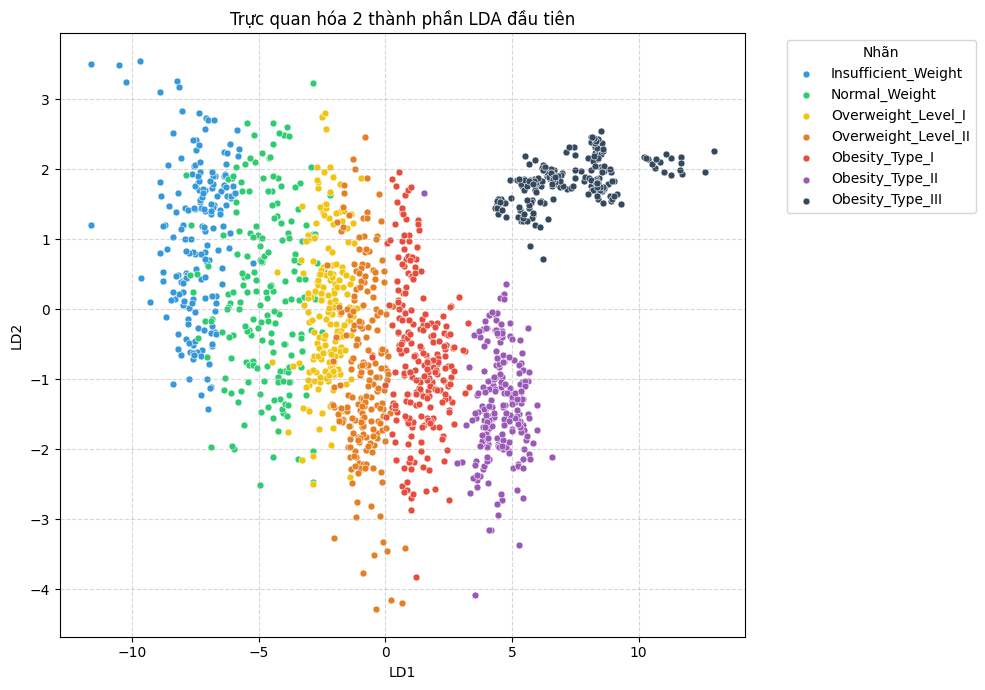

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_lda = pd.read_csv("/content/X_train_lda_2.csv")

label_map = {
    0: "Insufficient_Weight",
    1: "Normal_Weight",
    2: "Overweight_Level_I",
    3: "Overweight_Level_II",
    4: "Obesity_Type_I",
    5: "Obesity_Type_II",
    6: "Obesity_Type_III"
}

df_lda['NObeyesdad'] = df_lda['NObeyesdad'].map(label_map)

label_order = list(label_map.values())
colors = ["#3498db", "#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#9b59b6", "#34495e"]

plt.figure(figsize=(10, 7))

for label, color in zip(label_order, colors):
    subset = df_lda[df_lda["NObeyesdad"] == label]
    if not subset.empty:
        plt.scatter(
            subset["LD1"],
            subset["LD2"],
            label=label,
            color=color,
            alpha=1,
            edgecolors='w',
            linewidth=0.4,
            s=25
        )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Trực quan hóa 2 thành phần LDA đầu tiên")
plt.legend(title="Nhãn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Đánh giá kết quả sau giảm chiều

Linear Discriminant Analysis cho thấy khả năng phân tách các lớp dữ liệu khá rõ rệt, đặc biệt ở thành phần LD1.

Cụ thể, lớp Obesity_Type_III (xám đậm) được tách biệt hoàn toàn ở khu vực góc phải phía trên, cho thấy đây là nhóm có đặc trưng rất rõ ràng và LDA phân biệt tốt nhất trong toàn bộ tập dữ liệu. Đồng thời, LD1 đóng vai trò quan trọng trong việc phân tách chính giữa các lớp: khi quan sát theo trục ngang, có thể thấy xu hướng rõ ràng từ các nhóm có mức độ béo phì thấp như Insufficient_Weight và Normal_Weight ở phía bên trái, dần chuyển sang các nhóm có mức độ béo phì cao hơn ở phía bên phải. Điều này phản ánh đúng xu hướng y khoa thực tế về mức độ tăng dần của béo phì.

Tuy nhiên, vẫn tồn tại một số hạn chế trong khả năng phân tách của mô hình. Các lớp Insufficient_Weight (xanh dương), Normal_Weight (xanh lá) và Overweight_Level_I (vàng) bị chồng lấn đáng kể tại khu vực trung tâm bên trái, cho thấy đây là những nhóm khó phân biệt nhất và là nguồn gây nhiễu chính trong không gian LD, phù hợp với giá trị Silhouette Score khoảng 0.41. Bên cạnh đó, hai lớp Obesity_Type_I (đỏ) và Obesity_Type_II (tím) cũng có hiện tượng chồng lấn nhất định, làm giảm độ tách biệt giữa các nhóm trung gian.

Ngoài ra, thành phần LD2 đóng góp khá hạn chế trong việc phân tách dữ liệu. Các lớp phân bố dọc theo trục này nhưng không hình thành ranh giới rõ ràng, cho thấy LD2 chủ yếu mang tính bổ trợ và không phải trục phân biệt chính giữa các lớp.

##2.5 So sánh PCA với LDA và đánh giá kết quả giảm chiều

Từ 2 kết quả trên cho thấy LDA vượt trội hơn PCA trong việc giảm chiều cho bộ dữ liệu này. Trong khi PCA chỉ tối ưu hóa phương sai tổng thể mà không quan tâm đến nhãn lớp, dẫn đến các class bị chồng lấp gần như hoàn toàn trong không gian chiếu, LDA tập trung tối đa hóa khả năng phân tách giữa các lớp, tạo ra không gian chiếu có cấu trúc rõ ràng hơn.

